<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 1, Representación Temporal**

Importamos lo necesario

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### **A) Panel Data**

Generamos datos sintéticos

In [ ]:
np.random.seed(42)

Definimos la variable para los meses

In [ ]:
meses = np.arange(1, 25)

In [ ]:
print(meses)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]


Datos por ciudad

In [ ]:
buenos_aires = (
    1000 + 20*meses +
    100*np.sin(meses/3) +
    np.random.normal(0, 30, len(meses))
)

cordoba = (
    800 + 15*meses +
    80*np.sin(meses/3) +
    np.random.normal(0, 30, len(meses))
)

rosario = (
    700 + 18*meses +
    90*np.sin(meses/3) +
    np.random.normal(0, 30, len(meses))
)

mendoza = (
    600 + 12*meses +
    70*np.sin(meses/3) +
    np.random.normal(0, 30, len(meses))
)

Graficamos las series temporales

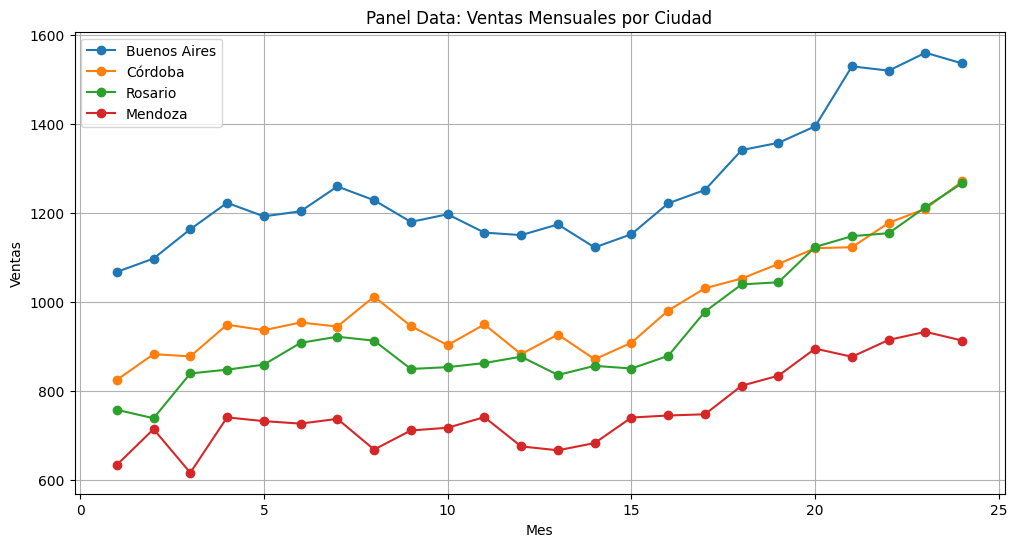

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(meses, buenos_aires, marker='o', label='Buenos Aires')
plt.plot(meses, cordoba, marker='o', label='Córdoba')
plt.plot(meses, rosario, marker='o', label='Rosario')
plt.plot(meses, mendoza, marker='o', label='Mendoza')

plt.title('Panel Data: Ventas Mensuales por Ciudad')
plt.xlabel('Mes')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)

plt.show()

---

### **B) Event-based temporal data**

Definimos valores randómicos

In [ ]:
event_times = np.sort(
    np.random.randint(0, 600, 50)
)

In [ ]:
print(event_times)

[  1  52  80 112 112 112 122 123 129 143 183 186 197 200 202 219 224 224
 232 233 246 258 267 279 293 317 325 345 348 358 373 384 385 386 400 402
 402 410 415 438 441 455 463 471 496 509 510 510 563 565]


Definimos la cantidad de pasajeros que llegan en cada evento

In [ ]:
passengers = np.random.randint(1, 20, 50)

In [ ]:
print(passengers)

[19  7  9  1  8  7 18  8  1 11 18 10  3  7 16 16 17  2  1 16 12  5  5  9
  9  3 19 16 16  3  1 11 17  8  4  6  8  3 16  3 18 14 18  2  3 16  9  4
  1  4]


Visualizamos los resultados

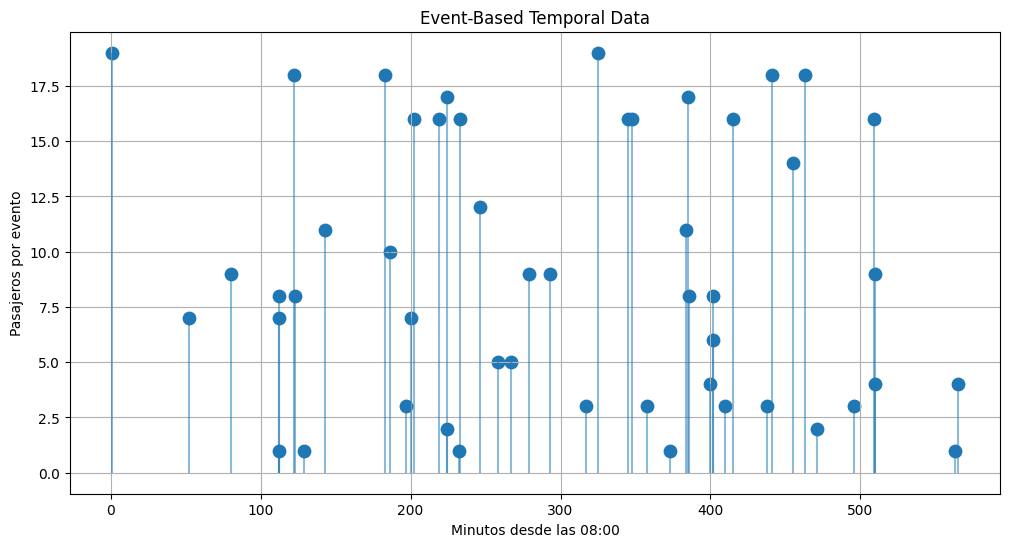

In [ ]:
plt.figure(figsize=(12, 6))

plt.scatter(
    event_times,
    passengers,
    s=80
)

plt.vlines(
    event_times,
    ymin=0,
    ymax=passengers,
    alpha=0.5
)

plt.title("Event-Based Temporal Data")
plt.xlabel("Minutos desde las 08:00")
plt.ylabel("Pasajeros por evento")
plt.grid(True)

plt.show()

### **C) Regular vs Irregular Data**

Definimos señal subyacente "real" (densa, como referencia)

In [ ]:
np.random.seed(42)

t_cont = np.linspace(1, 30, 500)
y_cont = 100 + 10*np.sin(t_cont/3)

### **C.1) Regular Time Series**

In [ ]:
t_regular = np.arange(1, 31)

In [ ]:
print(t_regular)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]


Realizamos muestreo regular: un punto por día, espaciado uniforme

In [ ]:
y_regular = 100 + 10*np.sin(t_regular/3) + np.random.normal(0, 2, len(t_regular))

### **C.2) Irregular Time Series**

Realizamos muestreo irregular: intervalos variables. Acumulamos saltos aleatorios, tiempos no uniformes (clusters y huecos)

In [ ]:
gaps = np.random.exponential(scale=1.8, size=30)
t_irregular = np.cumsum(gaps)
t_irregular = t_irregular[t_irregular <= 30]
y_irregular = 100 + 10*np.sin(t_irregular/3) + np.random.normal(0, 2, len(t_irregular))

In [ ]:
print(t_irregular)

[ 2.07495137  3.11911489  3.35338891  4.58377392  4.64676262  8.96752382
  9.50654782 11.46180825 12.1341921  13.45559171 14.87979455 15.24769403
 21.53474687 24.22078855 29.2699585 ]


Visualizamos

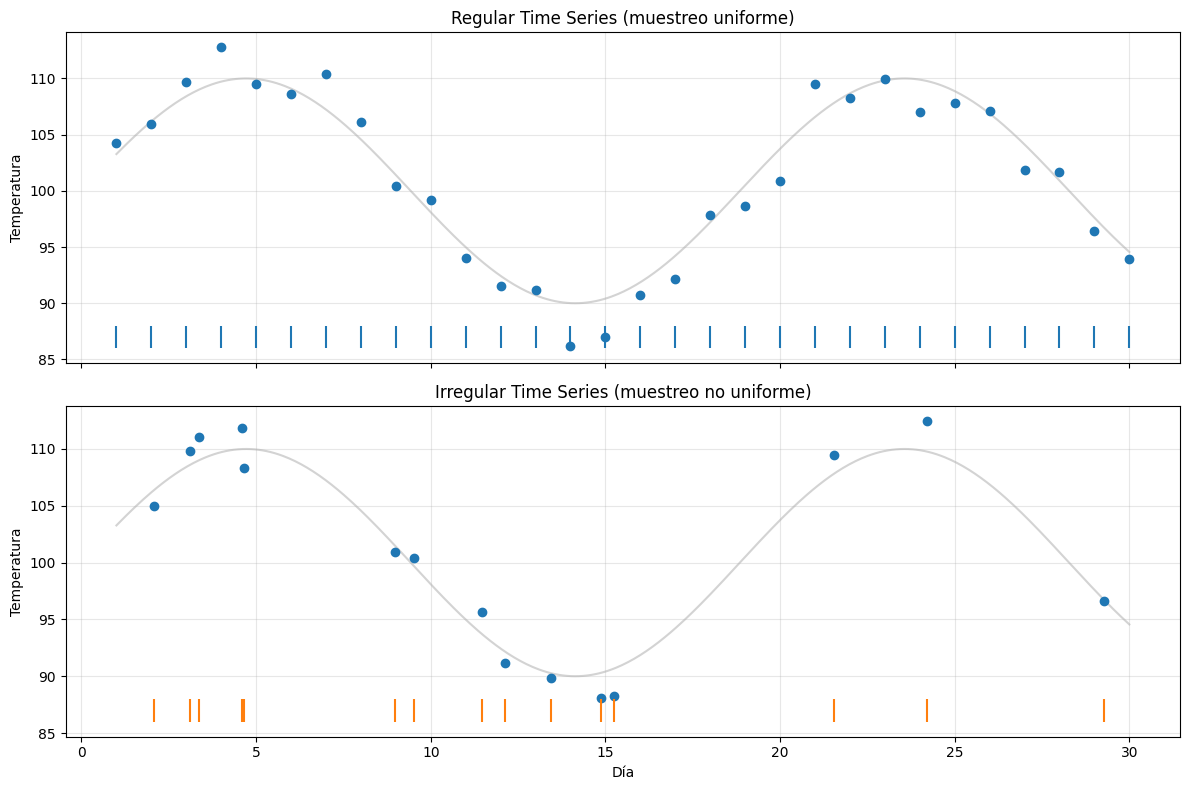

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Regular
axes[0].plot(t_cont, y_cont, color='lightgray', zorder=0, label='Señal subyacente')
axes[0].plot(t_regular, y_regular, marker='o', linestyle='none')
axes[0].vlines(t_regular, 86, 88, color='C0')       # "rug": marca cada tiempo de muestreo
axes[0].set_title("Regular Time Series (muestreo uniforme)")
axes[0].set_ylabel("Temperatura")
axes[0].grid(True, alpha=0.3)

# Irregular
axes[1].plot(t_cont, y_cont, color='lightgray', zorder=0)
axes[1].plot(t_irregular, y_irregular, marker='o', linestyle='none')
axes[1].vlines(t_irregular, 86, 88, color='C1')     # rug con espaciado desigual
axes[1].set_title("Irregular Time Series (muestreo no uniforme)")
axes[1].set_xlabel("Día")
axes[1].set_ylabel("Temperatura")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()